# 05 - FitNets feature-hint distillation for Student-120

This notebook implements the two-stage algorithm from Romero et al., **FitNets: Hints for
Thin Deep Nets** (ICLR 2015), and adapts it explicitly to binary Visual Wake Words.

The experiment answers one causal question: **does paper-style intermediate hint pretraining
improve the same Student-120 when both candidates subsequently receive the same Stage-2 KD?**

Three students begin from one immutable initialization:

1. `hard_control`: hard-label training only;
2. `kd_control`: FitNets Equation (2), without hint pretraining;
3. `fitnets_hint_kd`: Equation (3) hint pretraining, followed by the same Equation (2).

The teacher, feature taps, and convolutional regressor are training-only. The exported graph
must remain exactly the fixed MobileNetV1-0.25 Student-120 graph.

## Paper-derived training flow

```mermaid
flowchart LR
    I[One shared RGB view] --> T[Teacher-160 frozen]
    I --> S[Student-120 shared initialization]
    T --> H[Middle teacher hint u_h]
    S --> G[Middle student guided feature v_g]
    G --> R[Training-only convolutional regressor r]
    H --> L1[Stage 1: hint loss - Eq. 3]
    R --> L1
    L1 --> P[Hint-pretrained student prefix]
    P --> K[Stage 2: whole-student KD - Eq. 2]
    T --> K
    Y[Hard VWW label] --> K
    K --> D[Student-only deployable graph]
```

Paper equations used here:

$$L_{HT}=\frac{1}{2}\lVert u_h(x)-r(v_g(x))\rVert_2^2$$

$$L_{KD}=H(y,p_s)+\lambda H(p_t^{\tau},p_s^{\tau})$$

with the paper anchor $\tau=3$ and a linear $\lambda$ decay from 4 to 1.

## Adaptation register: paper versus this VWW experiment

| Decision | FitNets paper | This notebook | Reason |
|---|---|---|---|
| Training | Hint stage, then whole-network KD | Same | Core algorithm must remain intact |
| Hint location | Middle teacher and student layers | `conv_pw_6_relu` in both | Same output-stride/receptive-field role |
| Regressor | Convolutional, matching teacher hint shape/nonlinearity | Resize + 1x1 ReLU convolution | Student uses 120 px while teacher uses 160 px |
| Hint objective | Half squared L2 norm | Element-normalized half squared L2 | Same gradient direction; resolution-stable scale |
| Stage-2 temperature | 3 | 3 | Paper anchor |
| Stage-2 teacher weight | 4 linearly decayed to 1 | 4 linearly decayed to 1 | Paper curriculum |
| Student initialization | Uniform small random weights | Keras/MobileNet random initialization | Preserves the paper's from-scratch premise; all branches share one immutable checkpoint |
| Output | Multiclass softmax | Bernoulli/sigmoid equivalent | VWW is binary |
| Optimizer/epoch budget | RMSProp, long benchmark schedules | RMSProp, project-sized early-stopped schedule | Compute-budget adaptation |

No normalized-feature loss, extra hint, response-KD sweep, pruning, or QAT is included here.
Those are later ablations and must not contaminate the paper-derived anchor.

## 1 - Environment and immutable experiment contract

In [1]:
import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/vww-matplotlib")

ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), "Run from the repository or a subdirectory."

import sys
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

In [2]:
import hashlib
import json
import platform
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from vww_esp32.evaluation import (
    calibration_points,
    classification_metrics,
    expected_calibration_error,
    select_threshold,
)
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model

sns.set_theme(style="whitegrid", context="talk")

In [3]:
CONFIG_PATH = ROOT / "configs/distillation_fitnets_120.yaml"

In [4]:
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

SEED = int(config["project"]["seed"])
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Determinism warning:", exc)

In [5]:
ARTIFACT_DIR = ROOT / config["paths"]["artifacts"]
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
MODEL_DIR = ARTIFACT_DIR / "models"
REPORT_DIR = ARTIFACT_DIR / "reports"
FIGURE_DIR = ARTIFACT_DIR / "figures"
LOG_DIR = ARTIFACT_DIR / "logs"
for directory in (CHECKPOINT_DIR, MODEL_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TEACHER_SIZE = tuple(config["data"]["teacher_size"])
STUDENT_SIZE = tuple(config["data"]["student_size"])
BATCH_SIZE = int(config["data"]["batch_size"])
AUTOTUNE = tf.data.AUTOTUNE

# Safe experiment controls. Reuse is opt-in because stale checkpoints break causal comparison.
RUN_TRAINING = True
REUSE_CHECKPOINTS = False
RUN_INT8_EXPORT = True

In [6]:
def sha256_file(path, chunk_bytes=1 << 20):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()


paths = {
    key: ROOT / value
    for key, value in config["paths"].items()
    if key != "artifacts"
}
for key, path in paths.items():
    assert path.exists(), f"Missing {key}: {path}"

contract = {
    "config_sha256": sha256_file(CONFIG_PATH),
    "manifest_sha256": sha256_file(paths["manifest"]),
    "teacher_sha256": sha256_file(paths["teacher_model"]),
    "paper_sha256": sha256_file(paths["fitnets_paper"]),
    "seed": SEED,
    "teacher_size": TEACHER_SIZE,
    "student_size": STUDENT_SIZE,
    "tensorflow": tf.__version__,
    "python": platform.python_version(),
}
(REPORT_DIR / "runtime_contract.json").write_text(
    json.dumps(contract, indent=2), encoding="utf-8"
)
(REPORT_DIR / "config_snapshot.yaml").write_text(
    CONFIG_PATH.read_text(encoding="utf-8"), encoding="utf-8"
)
display(pd.Series(contract))

config_sha256      1e002d57b24e2e6cd3a124d8cf2bc4c8aff26632376299...
manifest_sha256    6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242...
teacher_sha256     8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03c...
paper_sha256       584ff258c88dd5b992b1df7977d856189840cdf89b0ff9...
seed                                                              42
teacher_size                                              (160, 160)
student_size                                              (120, 120)
tensorflow                                                    2.20.0
python                                                       3.10.13
dtype: object

## 2 - Dataset and corrected same-view RGB pipeline

In [7]:
manifest = pd.read_csv(paths["manifest"])
required_columns = {"image_id", "image_path", "split", "label"}
assert required_columns.issubset(manifest.columns)
assert manifest.image_id.is_unique

manifest["image_path"] = manifest.image_path.map(
    lambda value: str((ROOT / value).resolve()) if not Path(value).is_absolute() else value
)
assert manifest.image_path.map(lambda value: Path(value).exists()).all()

splits = {
    name: frame.reset_index(drop=True)
    for name, frame in manifest.groupby("split")
}
split_audit = pd.DataFrame(
    [
        {
            "split": name,
            "samples": len(frame),
            "positive_fraction": frame.label.mean(),
        }
        for name, frame in splits.items()
    ]
)
display(split_audit)

,split,samples,positive_fraction
0,test,2000,0.4905
1,train,12000,0.5000
2,val,2000,0.4945


In [8]:
def build_augmentation(seed):
    aug = config["augmentation"]
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal", seed=seed),
            tf.keras.layers.RandomTranslation(
                aug["translation_fraction"],
                aug["translation_fraction"],
                fill_mode="reflect",
                seed=seed + 1,
            ),
            tf.keras.layers.RandomBrightness(
                aug["brightness_delta"], value_range=(0.0, 1.0), seed=seed + 2
            ),
            tf.keras.layers.RandomContrast(aug["contrast_factor"], seed=seed + 3),
            tf.keras.layers.RandomSaturation(
                (1 - aug["saturation_delta"], 1 + aug["saturation_delta"]),
                value_range=(0.0, 1.0),
                seed=seed + 4,
            ),
            tf.keras.layers.GaussianNoise(aug["sensor_noise_stddev"], seed=seed + 5),
        ],
        name=f"shared_rgb_augmentation_{seed}",
    )


def decode_rgb(path):
    image = tf.io.decode_image(
        tf.io.read_file(path), channels=3, expand_animations=False
    )
    image.set_shape([None, None, 3])
    return tf.cast(image, tf.float32)

In [9]:
def make_dataset(frame, training, seed, batch_size=BATCH_SIZE):
    augmentation = build_augmentation(seed)
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame.image_path.astype(str), frame.label.astype("float32"))
    )
    if training:
        dataset = dataset.shuffle(
            min(len(frame), 4096), seed=seed, reshuffle_each_iteration=True
        )

    def prepare(path, label):
        # Decode once and augment once. Teacher and student receive the same scene.
        shared = tf.image.resize_with_pad(
            decode_rgb(path), *TEACHER_SIZE, antialias=True
        ) / 255.0
        if training:
            shared = augmentation(shared, training=True)
        shared = tf.clip_by_value(shared, 0.0, 1.0)
        return {
            "teacher_image": shared * 255.0,
            "student_image": tf.image.resize(
                shared, STUDENT_SIZE, antialias=True
            ) * 255.0,
        }, tf.reshape(label, (1,))

    return (
        dataset.map(prepare, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

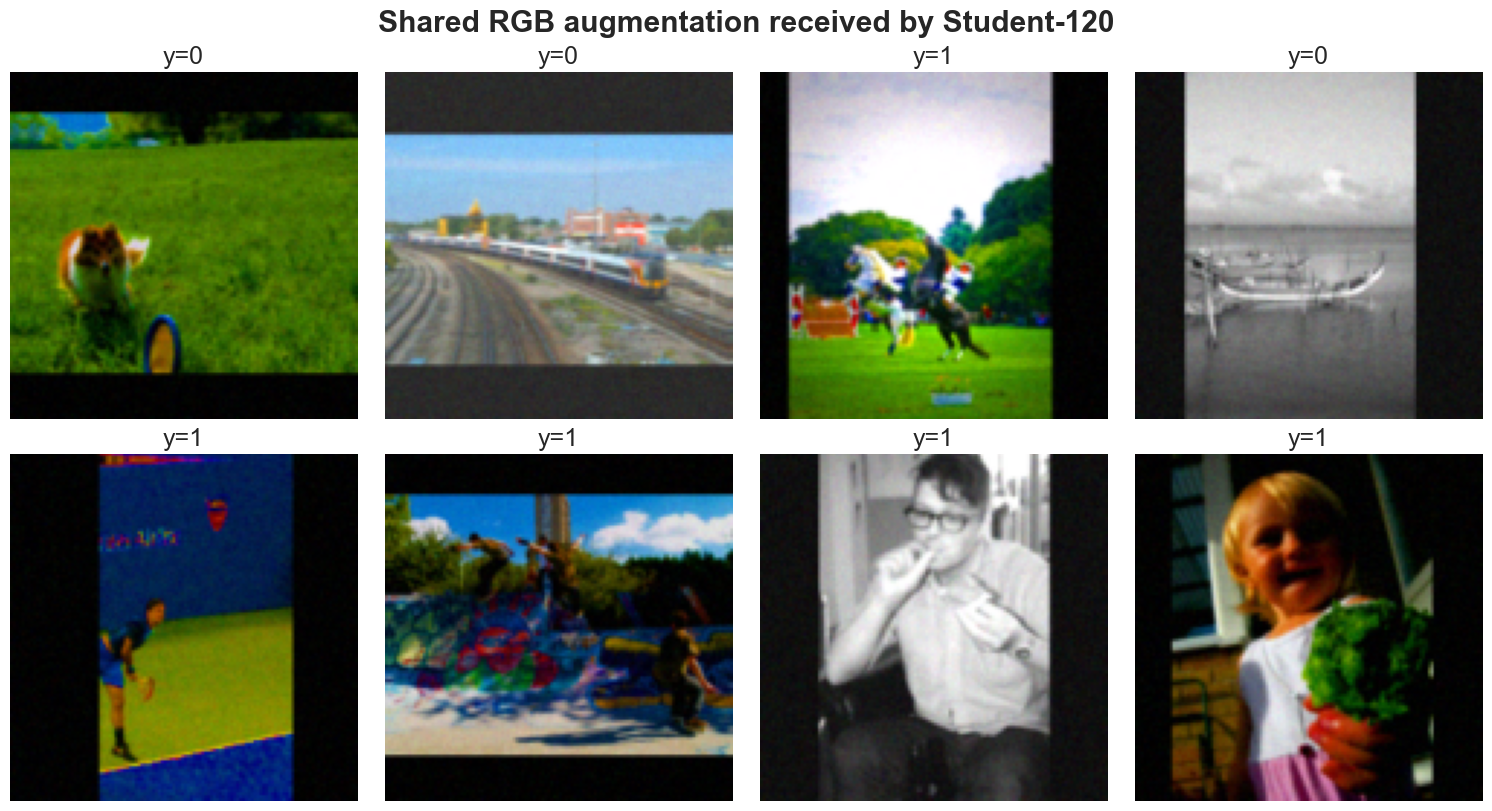

In [10]:
preview_inputs, preview_labels = next(
    iter(make_dataset(splits["train"].iloc[:8], True, SEED, batch_size=8))
)
fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
for index, axis in enumerate(axes.flat):
    axis.imshow(np.clip(preview_inputs["student_image"][index] / 255.0, 0, 1))
    axis.set_title(f"y={int(preview_labels[index, 0])}")
    axis.axis("off")
fig.suptitle("Shared RGB augmentation received by Student-120", fontweight="bold")
fig.savefig(FIGURE_DIR / "shared_rgb_views.png", dpi=180)
plt.show()

## 3 - Exact teacher, student, and middle-layer audit

In [11]:
teacher = tf.keras.models.load_model(paths["teacher_model"], compile=False)
teacher.trainable = False

In [12]:
reference_control = tf.keras.models.load_model(
    paths["reference_control_model"], compile=False
)

In [13]:
teacher_hint_layer = config["fitnets"]["teacher_hint_layer"]
student_guided_layer = config["fitnets"]["student_guided_layer"]
assert teacher.get_layer(teacher_hint_layer)
assert reference_control.get_layer(student_guided_layer)

In [14]:
def build_student_core(weights=None):
    image = tf.keras.Input((*STUDENT_SIZE, 3), name="image")
    normalized = tf.keras.layers.Rescaling(
        1 / 127.5, offset=-1, name="normalize"
    )(image)
    backbone = tf.keras.applications.MobileNet(
        input_tensor=normalized,
        input_shape=(*STUDENT_SIZE, 3),
        alpha=float(config["student"]["width_multiplier"]),
        include_top=False,
        weights=weights,
    )
    features = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average"
    )(backbone.output)
    features = tf.keras.layers.Dropout(
        config["student"]["dropout"], name="student_dropout"
    )(features)
    logits = tf.keras.layers.Dense(
        1,
        kernel_regularizer=tf.keras.regularizers.l2(config["student"]["l2"]),
        name="person_logit",
    )(features)
    return tf.keras.Model(image, logits, name="student_120_fitnets_logits")


def probability_view(core, name):
    probability = tf.keras.layers.Activation(
        "sigmoid", name="person_probability"
    )(core.output)
    return tf.keras.Model(core.input, probability, name=name)


def feature_view(model, layer_name, include_output=False):
    outputs = [model.output, model.get_layer(layer_name).output] if include_output else model.get_layer(layer_name).output
    return tf.keras.Model(model.input, outputs)

In [15]:
initialization = config["student"]["initialization"]
initialization = None if initialization in (None, "none", "random") else initialization
tf.keras.utils.set_random_seed(SEED)
probe_core = build_student_core(weights=initialization)
probe_model = probability_view(probe_core, "fitnets_probe")

assert probe_model.count_params() == reference_control.count_params() == 218801
assert probe_model.input_shape[1:] == (*STUDENT_SIZE, 3)

teacher_shape = tuple(teacher.get_layer(teacher_hint_layer).output.shape)
student_shape = tuple(probe_core.get_layer(student_guided_layer).output.shape)
stage_audit = pd.DataFrame(
    [
        {
            "network": "teacher",
            "layer": teacher_hint_layer,
            "shape": str(teacher_shape),
            "input": str(teacher.input_shape),
            "effective_spatial_reduction": TEACHER_SIZE[0] / teacher_shape[1],
        },
        {
            "network": "student",
            "layer": student_guided_layer,
            "shape": str(student_shape),
            "input": str(probe_core.input_shape),
            "effective_spatial_reduction": STUDENT_SIZE[0] / student_shape[1],
        },
    ]
)
stage_audit.to_csv(REPORT_DIR / "fitnets_stage_audit.csv", index=False)
display(stage_audit)

,network,layer,shape,input,effective_spatial_reduction
0,teacher,conv_pw_6_relu,"(None, 10, 10, 256)","(None, 160, 160, 3)",16.000000
1,student,conv_pw_6_relu,"(None, 7, 7, 128)","(None, 120, 120, 3)",17.142857


In [16]:
layer_table, liveness, static_profile = profile_model(
    probe_model, batch_size=1, training_batch_size=BATCH_SIZE
)
layer_table.to_csv(REPORT_DIR / "student_layer_profile.csv", index=False)
liveness.to_csv(REPORT_DIR / "student_activation_liveness.csv", index=False)
(REPORT_DIR / "student_static_profile.json").write_text(
    json.dumps(static_profile, indent=2), encoding="utf-8"
)
display(pd.Series(static_profile))

model_name                                                                                 fitnets_probe
layers                                                                                                91
parameters                                                                                        218801
trainable_parameters                                                                              213329
non_trainable_parameters                                                                            5472
float32_weight_bytes                                                                              875204
global_weight_sparsity                                                                          0.025014
global_weight_near_zero_fraction                                                                0.025014
global_kernel_sparsity                                                                               0.0
global_kernel_near_zero_fraction                       

## 4 - Stage 1: paper Equation (3) and convolutional regressor

In [ ]:
def build_regressor(
        student_shape, 
        teacher_shape
):
    guided = tf.keras.Input(student_shape[1:], name="student_guided_feature")
    # The paper uses a convolutional regressor whose output matches the hint.
    # Because the two networks consume different input resolutions, spatial resize is
    # required before the 1x1 channel projection.
    projected = tf.keras.layers.Resizing(
        teacher_shape[1], 
        teacher_shape[2], 
        interpolation="bilinear", 
        name="match_hint_spatial"
    )(guided)

    # Convolution Regressor instead of Fully-Connected Regressor (white-paper) to
    # reduced dramatically parameters and memory consumption. 
    projected = tf.keras.layers.Conv2D(
        teacher_shape[-1],
        config["fitnets"]["regressor_kernel_size"],
        padding="same",
        activation=config["fitnets"]["regressor_activation"],
        kernel_initializer=tf.keras.initializers.RandomUniform(-0.005, 0.005, seed=SEED),
        name="hint_regressor",
    )(projected)
    
    return tf.keras.Model(
        guided, 
        projected, 
        name="training_only_hint_regressor"
    )

$$
\|F_T^{(i)}-\hat F_S^{(i)}\|_2^2
=
\sum_{h=1}^{H}
\sum_{w=1}^{W}
\sum_{c=1}^{C}
\left(
F_{T,i,h,w,c}
-
\hat F_{S,i,h,w,c}
\right)^2
$$

$$L_{HT}=\frac{1}{2}\lVert u_h(x)-r(v_g(x))\rVert_2^2$$

In [18]:
def hint_loss(
        teacher_feature, 
        regressed_student_feature
):
    difference = tf.stop_gradient(teacher_feature) - regressed_student_feature
    squared_norm = tf.reduce_sum(
        tf.square(difference), 
        axis=[1, 2, 3]
    )
    if config["fitnets"]["hint_loss_element_normalization"]:
        elements = tf.cast(
            tf.reduce_prod(tf.shape(difference)[1:]), 
            tf.float32
        )
        squared_norm = squared_norm / elements
    return 0.5 * tf.reduce_mean(squared_norm)

In [ ]:
# Mathematical and shape invariants for Equation (3).
probe_regressor = build_regressor(
    student_shape, 
    teacher_shape
)

In [ ]:
random_student_feature = tf.random.uniform(
    (2, *student_shape[1:]), 
    seed=SEED
)

In [21]:
projected_feature = probe_regressor(random_student_feature)

In [22]:
assert tuple(projected_feature.shape[1:]) == teacher_shape[1:]
assert float(hint_loss(projected_feature, projected_feature)) < 1e-8
assert np.isfinite(
    float(hint_loss(tf.random.uniform(projected_feature.shape), projected_feature))
)
print("FitNets Equation (3) shape and finite-loss invariants passed.")

FitNets Equation (3) shape and finite-loss invariants passed.


HINT

In [ ]:
class HintTrainer(tf.keras.Model):
    def __init__(
            self, 
            student_core, 
            teacher_model, 
            regressor
    ):
        super().__init__()
        self.student_core = student_core
        self.regressor = regressor
        self.student_hint = feature_view(student_core, student_guided_layer)
        self.teacher_hint = feature_view(teacher_model, teacher_hint_layer)
        self.hint_metric = tf.keras.metrics.Mean(name="hint_loss")

    @property
    def metrics(self):
        return [self.hint_metric]

    def _loss(self, inputs, training):
        student_feature = self.student_hint(
            inputs["student_image"], training=training
        )
        teacher_feature = self.teacher_hint(
            inputs["teacher_image"], training=False
        )

        prediction = self.regressor(student_feature, training=training)
        
        return hint_loss(
            teacher_feature, 
            prediction
        )

    def train_step(self, data):
        inputs, _ = data
        with tf.GradientTape() as tape:
            loss = self._loss(inputs, training=True)

        variables = self.student_hint.trainable_variables + self.regressor.trainable_variables
        
        gradients = tape.gradient(loss, variables)
        
        self.optimizer.apply_gradients(
            [(gradient, variable) for gradient, variable in zip(gradients, variables) if gradient is not None]
        )
        self.hint_metric.update_state(loss)
        return {
            "hint_loss": self.hint_metric.result()
        }

    def test_step(self, data):
        inputs, _ = data
        loss = self._loss(inputs, training=False)
        self.hint_metric.update_state(loss)
        return {
            "hint_loss": self.hint_metric.result()
        }

In [24]:
class BestHintCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, core_path, regressor_path):
        super().__init__()
        self.core_path = Path(core_path)
        self.regressor_path = Path(regressor_path)
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        value = (logs or {}).get("val_hint_loss")
        if value is not None and float(value) < self.best:
            self.best = float(value)
            self.model.student_core.save(self.core_path)
            self.model.regressor.save(self.regressor_path)

In [25]:
def hint_callbacks(core_path, regressor_path):
    return [
        BestHintCheckpoint(core_path, regressor_path),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_hint_loss",
            mode="min",
            patience=config["training"]["early_stopping_patience"],
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_hint_loss",
            mode="min",
            factor=0.3,
            patience=config["training"]["reduce_lr_patience"],
            min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR / "fitnets_hint_stage.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

In [ ]:
INITIAL_CORE = CHECKPOINT_DIR / "shared_initial_student.keras"
HINTED_CORE = CHECKPOINT_DIR / "fitnets_hint_student.keras"
HINT_REGRESSOR = CHECKPOINT_DIR / "fitnets_hint_regressor.keras"

if RUN_TRAINING and not (REUSE_CHECKPOINTS and INITIAL_CORE.exists()):
    tf.keras.utils.set_random_seed(SEED)

    # built student
    initial_core = build_student_core(weights=initialization)
    initial_core.save(INITIAL_CORE)
    
assert INITIAL_CORE.exists()

In [27]:
if RUN_TRAINING and not (
    REUSE_CHECKPOINTS and HINTED_CORE.exists() and HINT_REGRESSOR.exists()
):
    hint_core = tf.keras.models.load_model(INITIAL_CORE, compile=False)
    hint_regressor = build_regressor(
        student_shape, 
        teacher_shape
    )
    hint_trainer = HintTrainer(
        hint_core, 
        teacher, 
        hint_regressor
    )
    hint_trainer.compile(
        optimizer=tf.keras.optimizers.RMSprop(
            learning_rate=config["training"]["hint_learning_rate"]
        )
    )
    hint_trainer.fit(
        make_dataset(splits["train"], True, SEED),
        validation_data=make_dataset(splits["val"], False, SEED),
        epochs=config["training"]["hint_epochs"],
        callbacks=hint_callbacks(HINTED_CORE, HINT_REGRESSOR),
    )

assert HINTED_CORE.exists() and HINT_REGRESSOR.exists()

Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 99s 257ms/step - hint_loss: 0.5626 - val_hint_loss: 0.6888 - learning_rate: 3.0000e-04
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 98s 260ms/step - hint_loss: 0.2598 - val_hint_loss: 0.3754 - learning_rate: 3.0000e-04
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 110s 293ms/step - hint_loss: 0.2366 - val_hint_loss: 0.3540 - learning_rate: 3.0000e-04
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 131s 350ms/step - hint_loss: 0.2257 - val_hint_loss: 0.3457 - learning_rate: 3.0000e-04
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 130s 347ms/step - hint_loss: 0.2193 - val_hint_loss: 0.3397 - learning_rate: 3.0000e-04
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 117s 311ms/step - hint_loss: 0.2144 - val_hint_loss: 0.3323 - learning_rate: 3.0000e-04
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 119s 317ms/step - hint_loss: 0.2103 - val_hint_loss: 0.3259 - learning_rate: 3.0000e-04
Epoch 8/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 119s 318ms/step - hint_loss: 0.2063 - val_hint_loss: 0.3214 - lear

## 5 - Stage 2: paper Equation (2) with linear lambda curriculum

In [28]:
TEMPERATURE = float(config["training"]["temperature"])

In [29]:
assert TEMPERATURE == 3.0, "The registered paper anchor uses tau=3."

In [30]:
def probability_to_logit(probability, epsilon=1e-6):
    probability = tf.clip_by_value(probability, epsilon, 1.0 - epsilon)
    return tf.math.log(probability) - tf.math.log1p(-probability)


def binary_kd_cross_entropy(
        teacher_probability, 
        student_logit, 
        temperature
):
    teacher_logit = probability_to_logit(teacher_probability)
    soft_target = tf.sigmoid(teacher_logit / temperature)
    return tf.reduce_mean(
        tf.nn.sigmoid_cross_entropy_with_logits(
            labels=tf.stop_gradient(soft_target),
            logits=student_logit / temperature,
        )
    )

$$L_{KD}=H(y,p_s)+\lambda H(p_t^{\tau},p_s^{\tau})$$

In [31]:
# Binary Equation (2) invariants: matching logits minimize the soft CE gradient,
# and temperature three produces softer probabilities than temperature one.
anchor_logit = tf.constant([[-3.0], [0.5], [4.0]], tf.float32)
anchor_probability = tf.sigmoid(anchor_logit)

In [32]:
with tf.GradientTape() as tape:
    tape.watch(anchor_logit)
    matched_loss = binary_kd_cross_entropy(
        anchor_probability, 
        anchor_logit, 
        TEMPERATURE
    )
matched_gradient = tape.gradient(matched_loss, anchor_logit)

In [33]:
assert float(tf.reduce_max(tf.abs(matched_gradient))) < 1e-6
assert float(tf.reduce_max(tf.abs(tf.sigmoid(anchor_logit / TEMPERATURE) - 0.5))) < float(
    tf.reduce_max(tf.abs(tf.sigmoid(anchor_logit) - 0.5))
)
print("FitNets Equation (2) binary invariants passed.")

FitNets Equation (2) binary invariants passed.


STAGE 2

In [34]:
class Stage2Distiller(tf.keras.Model):
    def __init__(
            self, 
            student_core, 
            teacher_model, 
            use_teacher, 
            initial_lambda
    ):
        super().__init__()
        self.student_core = student_core
        self.teacher_model = teacher_model
        self.use_teacher = bool(use_teacher)
        self.lambda_value = tf.Variable(
            float(initial_lambda), 
            trainable=False, 
            dtype=tf.float32, 
            name="kd_lambda"
        )
        metric_names = [
            "loss", 
            "hard_loss", 
            "soft_loss", 
            "soft_component",
            "hard_gradient_norm", 
            "soft_gradient_norm", 
            "gradient_cosine", 
            "kd_weight",
        ]
        self.audit_metrics = {
            name: tf.keras.metrics.Mean(name=name) for name in metric_names
        }
        self.quality_metrics = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ]

    @property
    def metrics(self):
        return [*self.audit_metrics.values(), *self.quality_metrics]

    def _terms(
            self, 
            inputs, 
            labels, 
            training
    ):
        logits = self.student_core(inputs["student_image"], training=training)
        labels = tf.reshape(tf.cast(labels, tf.float32), (-1, 1))
        hard = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(labels=labels, logits=logits)
        )

        if self.use_teacher:
            teacher_probability = self.teacher_model(
                inputs["teacher_image"], training=False
            )
            soft = binary_kd_cross_entropy(
                teacher_probability, 
                logits, 
                TEMPERATURE
            )
        else:
            soft = tf.constant(0.0, tf.float32)

        regularization = tf.add_n(self.student_core.losses) if self.student_core.losses else 0.0
        soft_component = self.lambda_value * soft
        
        return labels, logits, hard, soft, soft_component, hard + soft_component + regularization

    def train_step(self, data):
        inputs, labels = data
        with tf.GradientTape(persistent=True) as tape:
            labels, logits, hard, soft, soft_component, total = self._terms(
                inputs, labels, training=True
            )
        variables = self.student_core.trainable_variables
        total_gradients = tape.gradient(total, variables)
        hard_gradients = tape.gradient(hard, variables)
        soft_gradients = tape.gradient(soft_component, variables)
        del tape

        self.optimizer.apply_gradients(
            [(gradient, variable) for gradient, variable in zip(total_gradients, variables) if gradient is not None]
        )
        hard_vector = tf.concat(
            [tf.reshape(g if g is not None else tf.zeros_like(v), [-1]) for g, v in zip(hard_gradients, variables)], axis=0
        )
        soft_vector = tf.concat(
            [tf.reshape(g if g is not None else tf.zeros_like(v), [-1]) for g, v in zip(soft_gradients, variables)], axis=0
        )
        cosine = tf.math.divide_no_nan(
            tf.reduce_sum(hard_vector * soft_vector),
            tf.norm(hard_vector) * tf.norm(soft_vector),
        )
        audit = {
            "loss": total,
            "hard_loss": hard,
            "soft_loss": soft,
            "soft_component": soft_component,
            "hard_gradient_norm": tf.linalg.global_norm([g for g in hard_gradients if g is not None]),
            "soft_gradient_norm": tf.linalg.global_norm([g for g in soft_gradients if g is not None]),
            "gradient_cosine": cosine,
            "kd_weight": self.lambda_value,
        }
        for name, value in audit.items():
            self.audit_metrics[name].update_state(value)
        for metric in self.quality_metrics:
            metric.update_state(labels, tf.sigmoid(logits))
        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        inputs, labels = data
        labels, logits, hard, soft, soft_component, total = self._terms(
            inputs, labels, training=False
        )
        audit = {
            "loss": total,
            "hard_loss": hard,
            "soft_loss": soft,
            "soft_component": soft_component,
            "hard_gradient_norm": 0.0,
            "soft_gradient_norm": 0.0,
            "gradient_cosine": 0.0,
            "kd_weight": self.lambda_value,
        }
        for name, value in audit.items():
            self.audit_metrics[name].update_state(value)
        for metric in self.quality_metrics:
            metric.update_state(labels, tf.sigmoid(logits))
        return {metric.name: metric.result() for metric in self.metrics}

Optimize Learning Rate Scheduler

In [36]:
class LinearLambdaDecay(tf.keras.callbacks.Callback):
    def __init__(self, start, end, epochs):
        super().__init__()
        self.start = float(start)
        self.end = float(end)
        self.epochs = int(epochs)

    def on_epoch_begin(self, epoch, logs=None):
        fraction = epoch / max(self.epochs - 1, 1)
        value = self.start + fraction * (self.end - self.start)
        self.model.lambda_value.assign(value)

In [37]:
class BestStudentCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, path):
        super().__init__()
        self.path = Path(path)
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        value = (logs or {}).get(config["training"]["monitor"])
        if value is not None and float(value) > self.best:
            self.best = float(value)
            self.model.student_core.save(self.path)


In [38]:
def stage2_callbacks(name, path, lambda_start, lambda_end):
    return [
        LinearLambdaDecay(
            lambda_start, 
            lambda_end, 
            config["training"]["stage2_epochs"]
        ),
        BestStudentCheckpoint(path),
        tf.keras.callbacks.EarlyStopping(
            monitor=config["training"]["monitor"],
            mode="max",
            patience=config["training"]["early_stopping_patience"],
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=config["training"]["monitor"],
            mode="max",
            factor=0.3,
            patience=config["training"]["reduce_lr_patience"],
            min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR / f"{name}.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

In [39]:
experiment_table = pd.DataFrame(
    [
        {
            "name": "hard_control",
            "start": "shared_initial",
            "hint_stage": False,
            "stage2_teacher": False,
            "lambda": "0",
        },
        {
            "name": "kd_control",
            "start": "shared_initial",
            "hint_stage": False,
            "stage2_teacher": True,
            "lambda": "4 -> 1",
        },
        {
            "name": "fitnets_hint_kd",
            "start": "hint_pretrained",
            "hint_stage": True,
            "stage2_teacher": True,
            "lambda": "4 -> 1",
        },
    ]
)
display(experiment_table)

,name,start,hint_stage,stage2_teacher,lambda
0,hard_control,shared_initial,False,False,0
1,kd_control,shared_initial,False,True,4 -> 1
2,fitnets_hint_kd,hint_pretrained,True,True,4 -> 1


In [40]:
def train_stage2_branch(
        name, 
        starting_checkpoint, 
        use_teacher
):
    checkpoint = CHECKPOINT_DIR / f"{name}_stage2.keras"

    if RUN_TRAINING and not (REUSE_CHECKPOINTS and checkpoint.exists()):
        tf.keras.utils.set_random_seed(SEED)

        student_core = tf.keras.models.load_model(starting_checkpoint, compile=False)

        start = config["training"]["lambda_start"] if use_teacher else 0.0
        end = config["training"]["lambda_end"] if use_teacher else 0.0

        trainer = Stage2Distiller(student_core, teacher, use_teacher, start)
        trainer.compile(
            optimizer=tf.keras.optimizers.RMSprop(
                learning_rate=config["training"]["stage2_learning_rate"]
            )
        )
        
        trainer.fit(
            make_dataset(splits["train"], True, SEED),
            validation_data=make_dataset(splits["val"], False, SEED),
            epochs=config["training"]["stage2_epochs"],
            callbacks=stage2_callbacks(name, checkpoint, start, end),
        )

    assert checkpoint.exists(), f"Missing trained checkpoint: {checkpoint}"
    core = tf.keras.models.load_model(checkpoint, compile=False)
    model = probability_view(core, name)
    model_path = MODEL_DIR / f"{name}.keras"
    model.save(model_path)
    return model_path

In [41]:
models = {
    "hard_control": train_stage2_branch("hard_control", INITIAL_CORE, False),
    "kd_control": train_stage2_branch("kd_control", INITIAL_CORE, True),
    "fitnets_hint_kd": train_stage2_branch("fitnets_hint_kd", HINTED_CORE, True),
}
models

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 112s 279ms/step - accuracy: 0.5130 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 41.1837 - hard_loss: 0.7080 - kd_weight: 0.0000e+00 - loss: 0.7080 - pr_auc: 0.5174 - precision: 0.5143 - recall: 0.4665 - soft_component: 0.0000e+00 - soft_gradient_norm: 0.0000e+00 - soft_loss: 0.0000e+00 - val_accuracy: 0.5055 - val_gradient_cosine: 0.0000e+00 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.7819 - val_kd_weight: 0.0000e+00 - val_loss: 0.7819 - val_pr_auc: 0.4945 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_soft_component: 0.0000e+00 - val_soft_gradient_norm: 0.0000e+00 - val_soft_loss: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 124s 332ms/step - accuracy: 0.5318 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 35.1073 - hard_loss: 0.6984 - kd_weight: 0.0000e+00 - loss: 0.6984 - pr_auc: 0.5356 - precision: 0.5323 - recall: 0.5243 - soft_component: 0.0000e+00 - soft_gradient_norm: 0.

{'hard_control': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/fitnets_student_120/models/hard_control.keras'),
 'kd_control': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/fitnets_student_120/models/kd_control.keras'),
 'fitnets_hint_kd': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/fitnets_student_120/models/fitnets_hint_kd.keras')}

## 6 - Optimization audit: did both FitNets stages behave correctly?

In [42]:
history_frames = []
for name in ("fitnets_hint_stage", "hard_control", "kd_control", "fitnets_hint_kd"):
    path = LOG_DIR / f"{name}.csv"
    if path.exists():
        frame = pd.read_csv(path)
        frame["run"] = name
        frame["epoch_index"] = np.arange(len(frame)) + 1
        history_frames.append(frame)
history = pd.concat(history_frames, ignore_index=True)
history.to_csv(REPORT_DIR / "training_history.csv", index=False)
display(history.groupby("run").agg(epochs=("epoch_index", "max")))

,epochs
run,
fitnets_hint_kd,20
fitnets_hint_stage,12
hard_control,20
kd_control,20


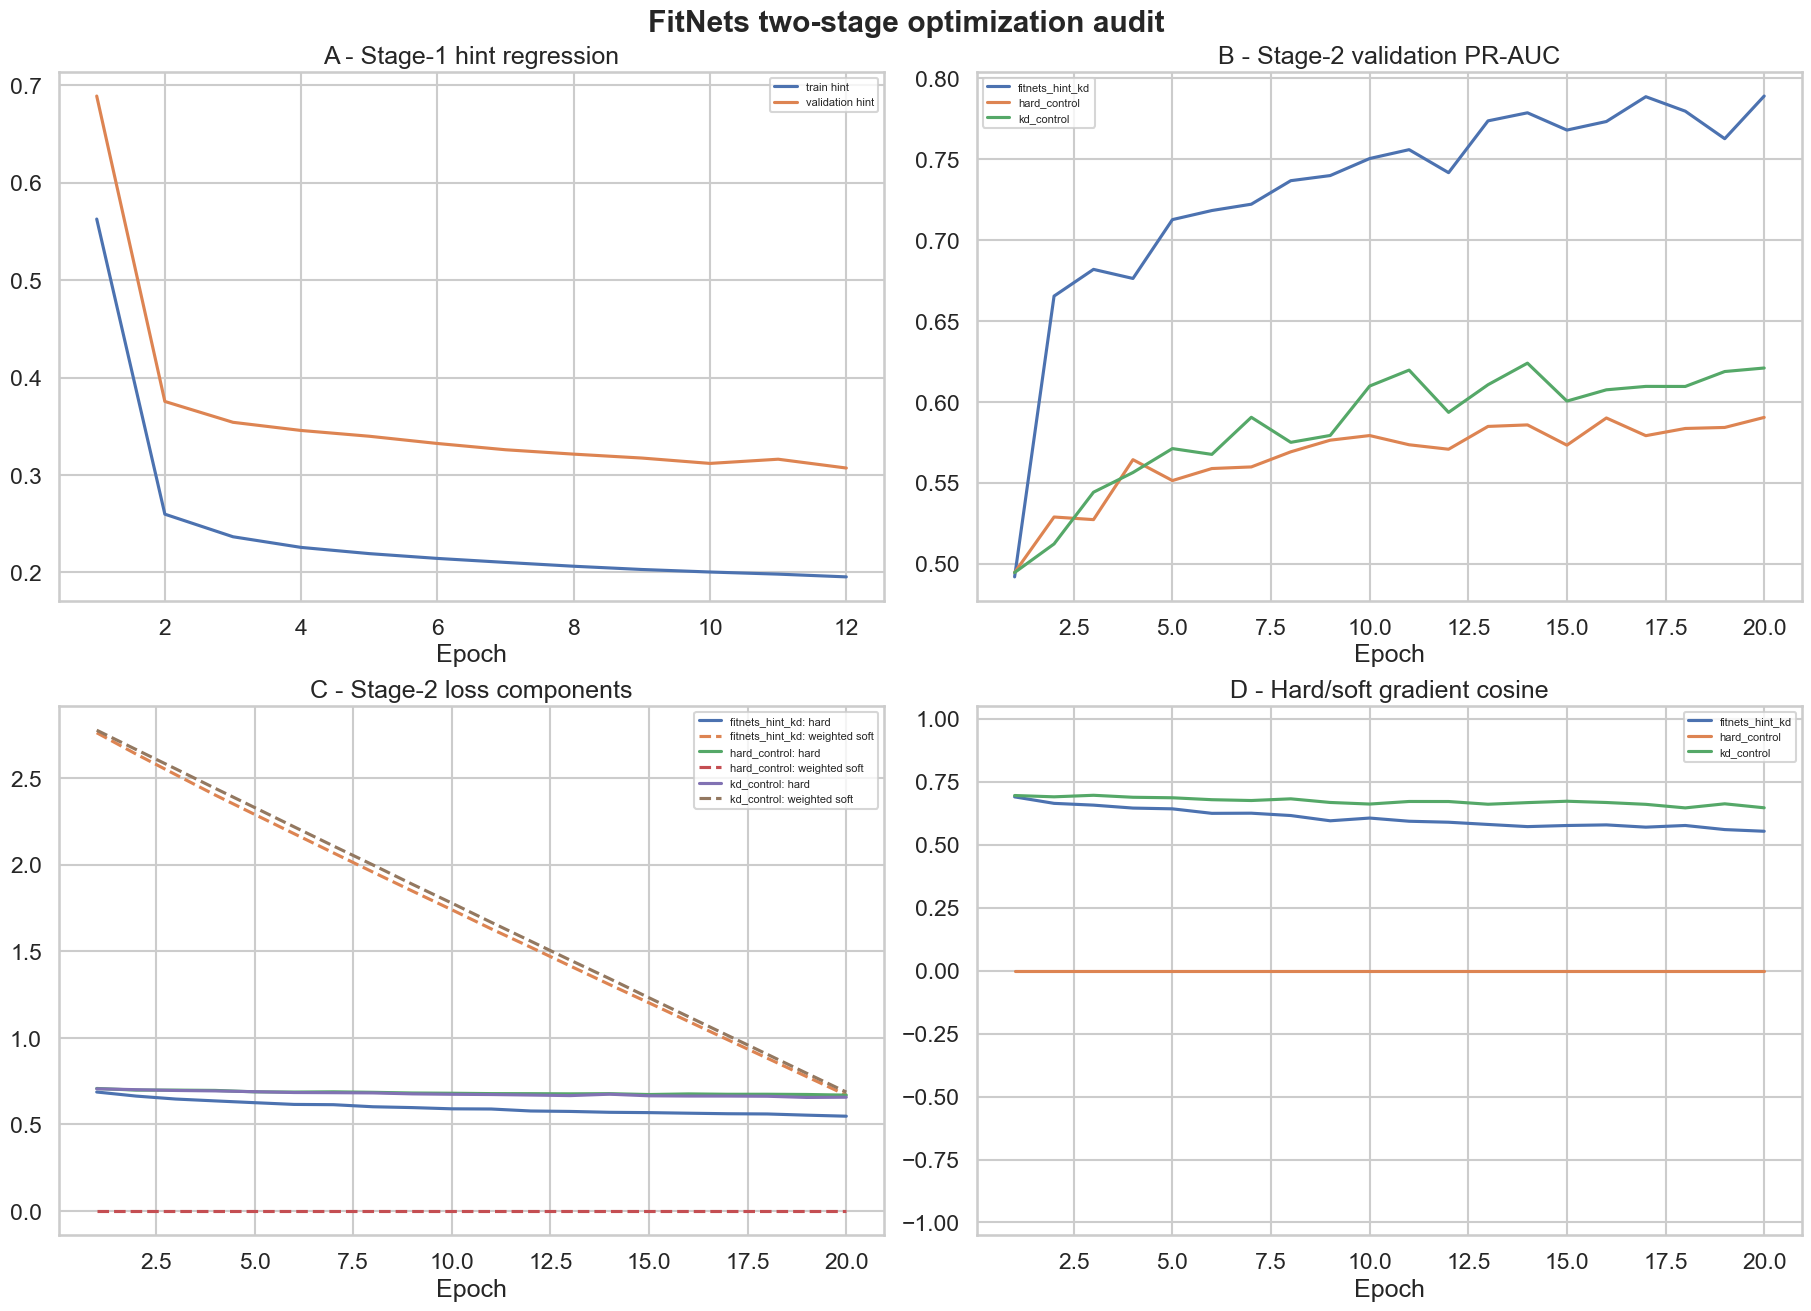

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)
hint_history = history[history.run == "fitnets_hint_stage"]
if len(hint_history):
    axes[0, 0].plot(hint_history.epoch_index, hint_history.hint_loss, label="train hint")
    axes[0, 0].plot(hint_history.epoch_index, hint_history.val_hint_loss, label="validation hint")

for name, frame in history[history.run != "fitnets_hint_stage"].groupby("run"):
    axes[0, 1].plot(frame.epoch_index, frame.val_pr_auc, label=name)
    axes[1, 0].plot(frame.epoch_index, frame.hard_loss, label=f"{name}: hard")
    axes[1, 0].plot(frame.epoch_index, frame.soft_component, "--", label=f"{name}: weighted soft")
    axes[1, 1].plot(frame.epoch_index, frame.gradient_cosine, label=name)

axes[0, 0].set_title("A - Stage-1 hint regression")
axes[0, 1].set_title("B - Stage-2 validation PR-AUC")
axes[1, 0].set_title("C - Stage-2 loss components")
axes[1, 1].set_title("D - Hard/soft gradient cosine")
axes[1, 1].set_ylim(-1.05, 1.05)
for axis in axes.flat:
    axis.set_xlabel("Epoch")
    axis.legend(fontsize=8)
fig.suptitle("FitNets two-stage optimization audit", fontweight="bold")
fig.savefig(FIGURE_DIR / "fitnets_training_audit.png", dpi=180)
plt.show()

## 7 - Frozen validation-selected test comparison

In [44]:
def make_eval_dataset(frame, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame.image_path.astype(str), frame.label.astype("float32"))
    )
    return (
        dataset.map(
            lambda path, label: (
                tf.image.resize_with_pad(
                    decode_rgb(path), *STUDENT_SIZE, antialias=True
                ),
                label,
            ),
            num_parallel_calls=AUTOTUNE,
        )
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )


def predict_keras(model, dataset):
    labels = np.concatenate([np.asarray(y).reshape(-1) for _, y in dataset]).astype(int)
    probabilities = np.asarray(model.predict(dataset, verbose=0)).reshape(-1)
    return labels, probabilities


val_ds = make_eval_dataset(splits["val"])
test_ds = make_eval_dataset(splits["test"])

In [45]:
quality_rows = []
probabilities = {}
validation_probabilities = {}
thresholds = {}

for name, path in models.items():
    model = tf.keras.models.load_model(path, compile=False)
    validation_labels, validation_probability = predict_keras(model, val_ds)
    test_labels, test_probability = predict_keras(model, test_ds)
    threshold = select_threshold(
        validation_labels,
        validation_probability,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=config["evaluation"]["minimum_recall"],
        false_positive_cost=config["evaluation"]["false_positive_cost"],
        false_negative_cost=config["evaluation"]["false_negative_cost"],
    )["threshold"]
    metrics = classification_metrics(test_labels, test_probability, threshold)
    metrics["ece_10"] = expected_calibration_error(test_labels, test_probability)
    quality_rows.append({"model": name, **metrics})
    probabilities[name] = test_probability
    validation_probabilities[name] = validation_probability
    thresholds[name] = threshold

quality = pd.DataFrame(quality_rows)
quality.to_csv(REPORT_DIR / "quality_comparison.csv", index=False)
display(quality)

,model,samples,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,confusion_matrix,positive_prevalence,predicted_positive_rate,ece_10
0,hard_control,2000,0.395,0.5700,0.538413,0.864424,0.663537,0.637925,0.614690,0.286555,"[[292, 727], [133, 848]]",0.4905,0.7875,0.016454
1,kd_control,2000,0.365,0.5450,0.520091,0.936799,0.668850,0.662779,0.642628,0.167812,"[[171, 848], [62, 919]]",0.4905,0.8835,0.030474
2,fitnets_hint_kd,2000,0.180,0.6985,0.649762,0.835882,0.731164,0.803070,0.798469,0.566241,"[[577, 442], [161, 820]]",0.4905,0.6310,0.156829


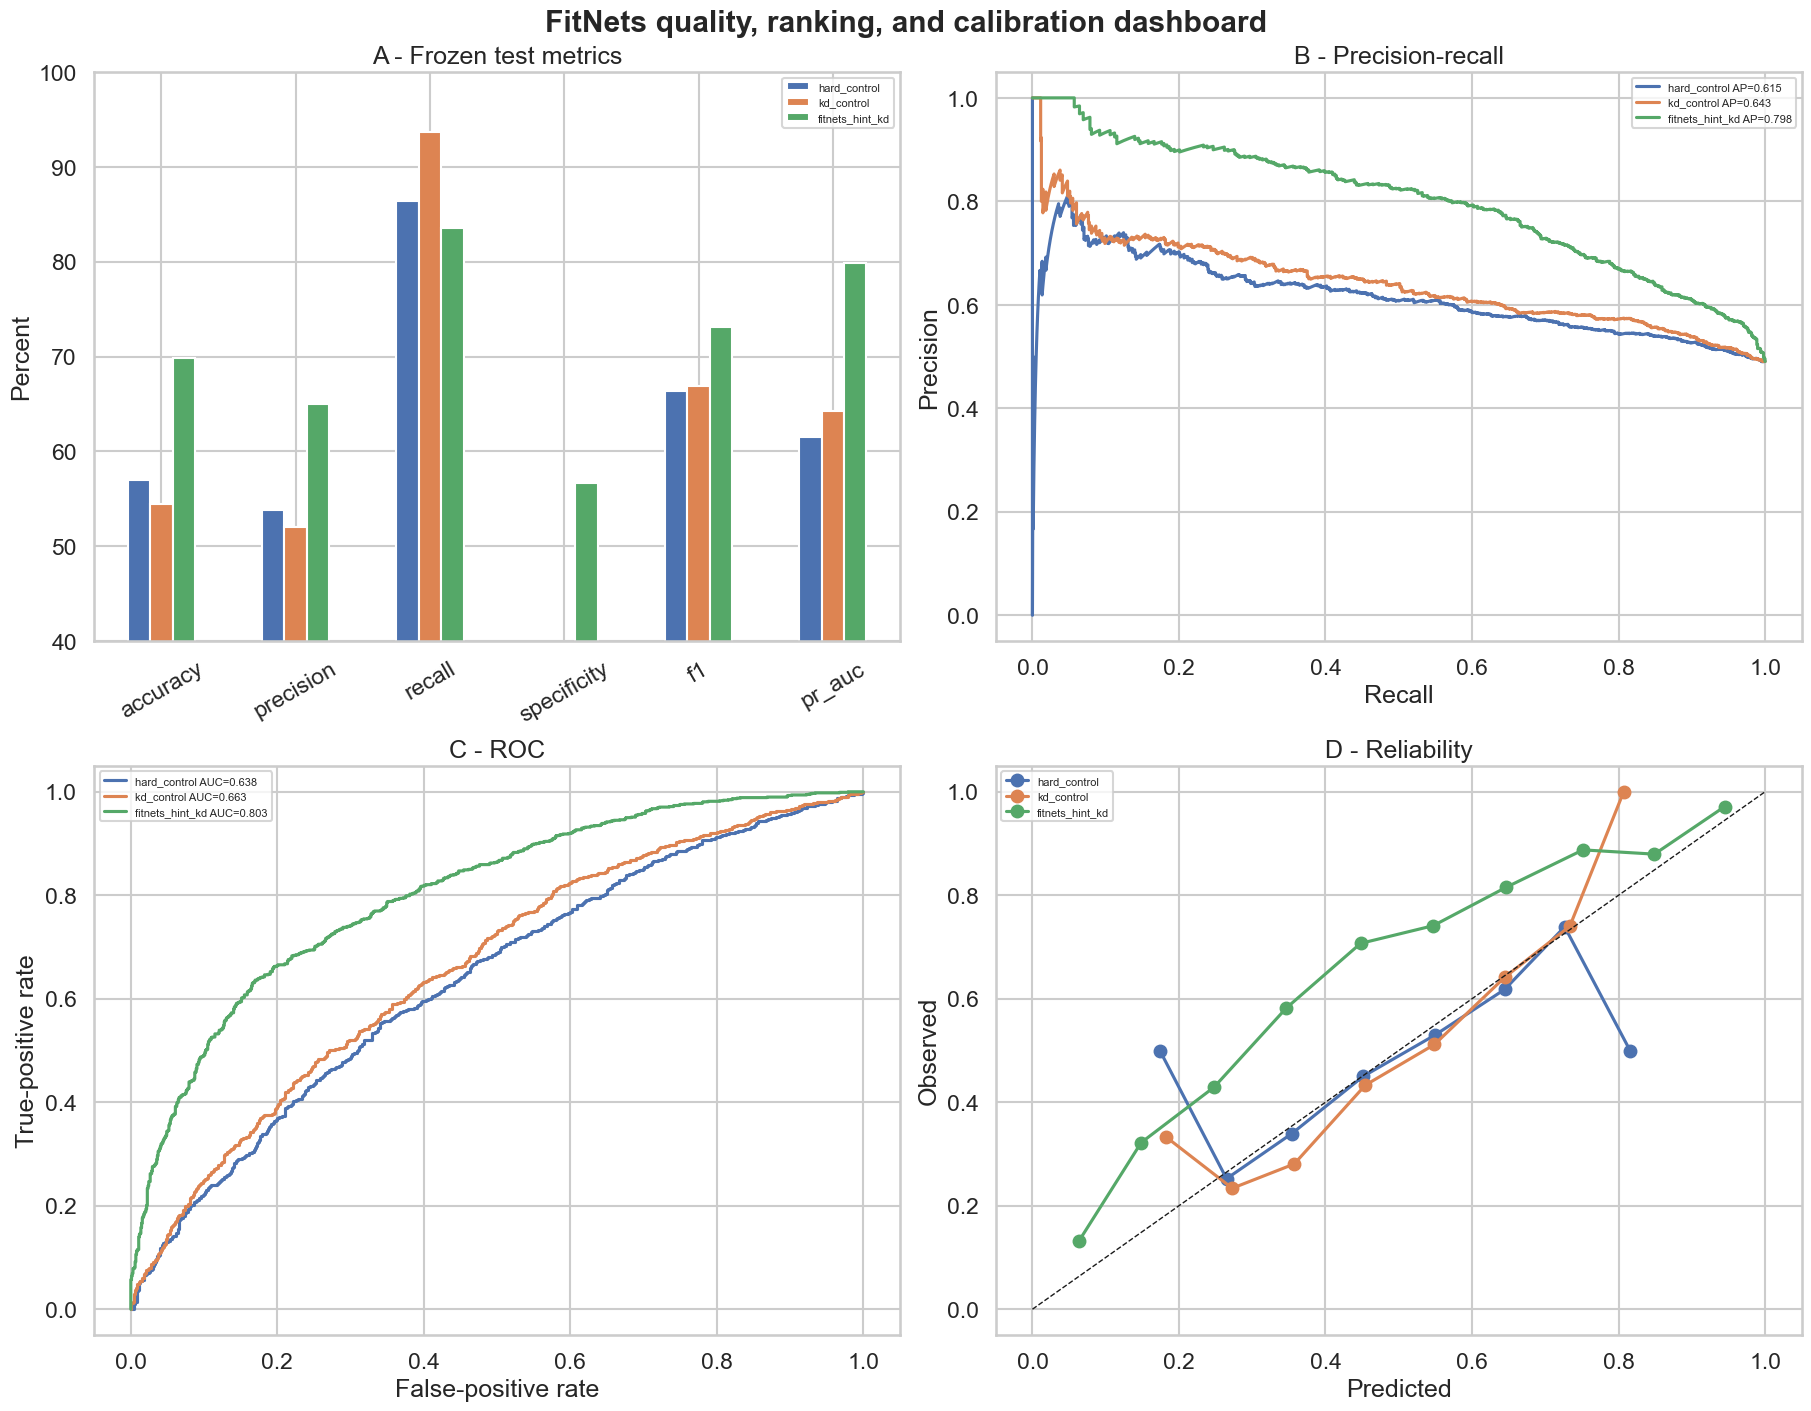

In [46]:
metrics_to_plot = ["accuracy", "precision", "recall", "specificity", "f1", "pr_auc"]
fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
(quality.set_index("model")[metrics_to_plot].T * 100).plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set(title="A - Frozen test metrics", ylabel="Percent", ylim=(40, 100))
axes[0, 0].tick_params(axis="x", rotation=30)

for name in models:
    precision, recall, _ = precision_recall_curve(test_labels, probabilities[name])
    false_positive_rate, true_positive_rate, _ = roc_curve(test_labels, probabilities[name])
    axes[0, 1].plot(recall, precision, label=f"{name} AP={average_precision_score(test_labels, probabilities[name]):.3f}")
    axes[1, 0].plot(false_positive_rate, true_positive_rate, label=f"{name} AUC={roc_auc_score(test_labels, probabilities[name]):.3f}")
    predicted, observed = calibration_points(test_labels, probabilities[name], bins=10)
    axes[1, 1].plot(predicted, observed, marker="o", label=name)

axes[0, 1].set(title="B - Precision-recall", xlabel="Recall", ylabel="Precision")
axes[1, 0].set(title="C - ROC", xlabel="False-positive rate", ylabel="True-positive rate")
axes[1, 1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1, 1].set(title="D - Reliability", xlabel="Predicted", ylabel="Observed")
for axis in axes.flat:
    axis.legend(fontsize=8)
fig.suptitle("FitNets quality, ranking, and calibration dashboard", fontweight="bold")
fig.savefig(FIGURE_DIR / "fitnets_quality_dashboard.png", dpi=180)
plt.show()

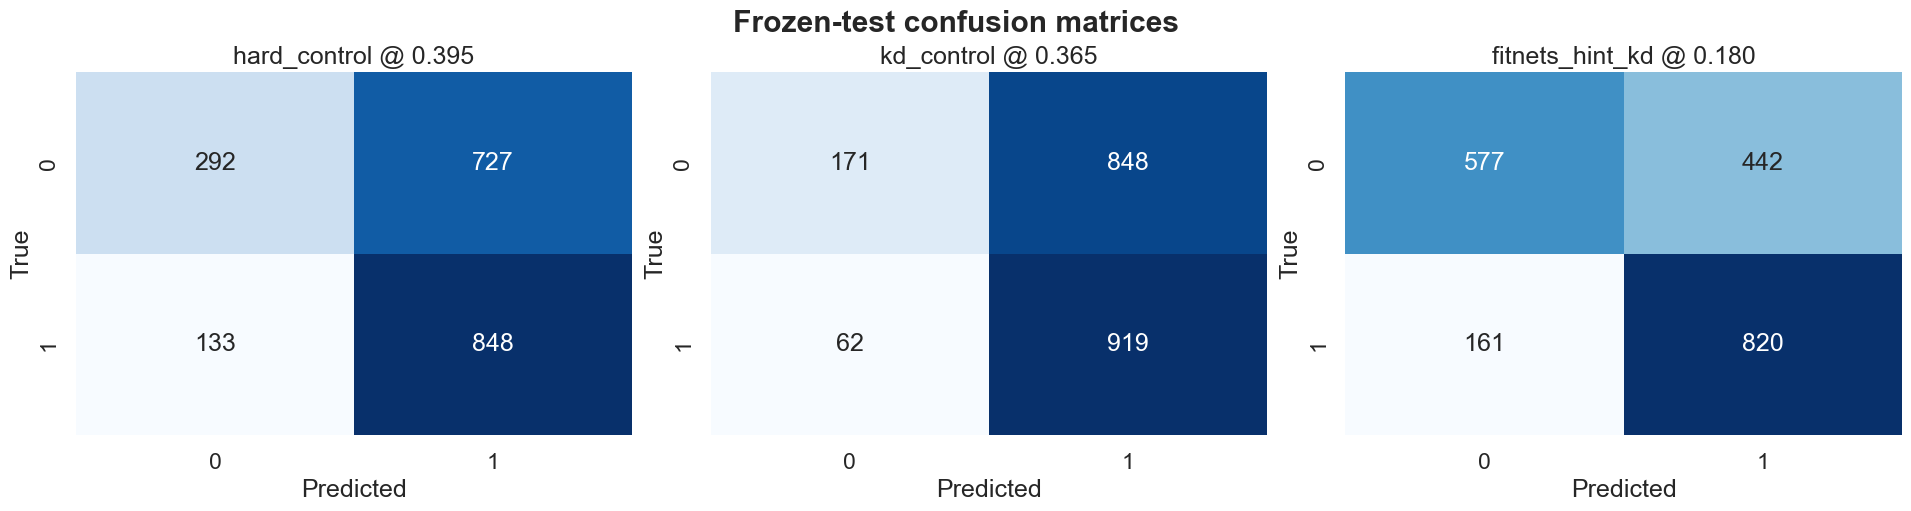

In [47]:
fig, axes = plt.subplots(1, len(models), figsize=(19, 5), constrained_layout=True)
for axis, (name, row) in zip(axes, quality.set_index("model").iterrows()):
    matrix = np.asarray(row.confusion_matrix)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set(
        title=f"{name} @ {row.threshold:.3f}",
        xlabel="Predicted",
        ylabel="True",
    )
fig.suptitle("Frozen-test confusion matrices", fontweight="bold")
fig.savefig(FIGURE_DIR / "fitnets_confusion_matrices.png", dpi=180)
plt.show()

## 8 - Paired bootstrap: FitNets hint stage versus the same KD without hints

In [48]:
rng = np.random.default_rng(SEED)
indices = np.arange(len(test_labels))
bootstrap_rows = []
for iteration in range(config["evaluation"]["bootstrap_samples"]):
    draw = rng.choice(indices, len(indices), replace=True)
    labels = test_labels[draw]
    control_probability = probabilities["kd_control"][draw]
    fitnets_probability = probabilities["fitnets_hint_kd"][draw]
    bootstrap_rows.append(
        {
            "iteration": iteration,
            "pr_auc_delta": average_precision_score(labels, fitnets_probability)
            - average_precision_score(labels, control_probability),
            "f1_delta": f1_score(
                labels, fitnets_probability >= thresholds["fitnets_hint_kd"]
            )
            - f1_score(labels, control_probability >= thresholds["kd_control"]),
        }
    )

bootstrap = pd.DataFrame(bootstrap_rows)
bootstrap.to_csv(REPORT_DIR / "paired_bootstrap.csv", index=False)
bootstrap_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "mean": bootstrap[metric].mean(),
            "ci_low": bootstrap[metric].quantile(0.025),
            "ci_high": bootstrap[metric].quantile(0.975),
            "probability_positive": (bootstrap[metric] > 0).mean(),
        }
        for metric in ("pr_auc_delta", "f1_delta")
    ]
)
bootstrap_summary.to_csv(REPORT_DIR / "bootstrap_summary.csv", index=False)
display(bootstrap_summary)

,metric,mean,ci_low,ci_high,probability_positive
0,pr_auc_delta,0.155706,0.127359,0.185791,1.0
1,f1_delta,0.062222,0.045731,0.081101,1.0


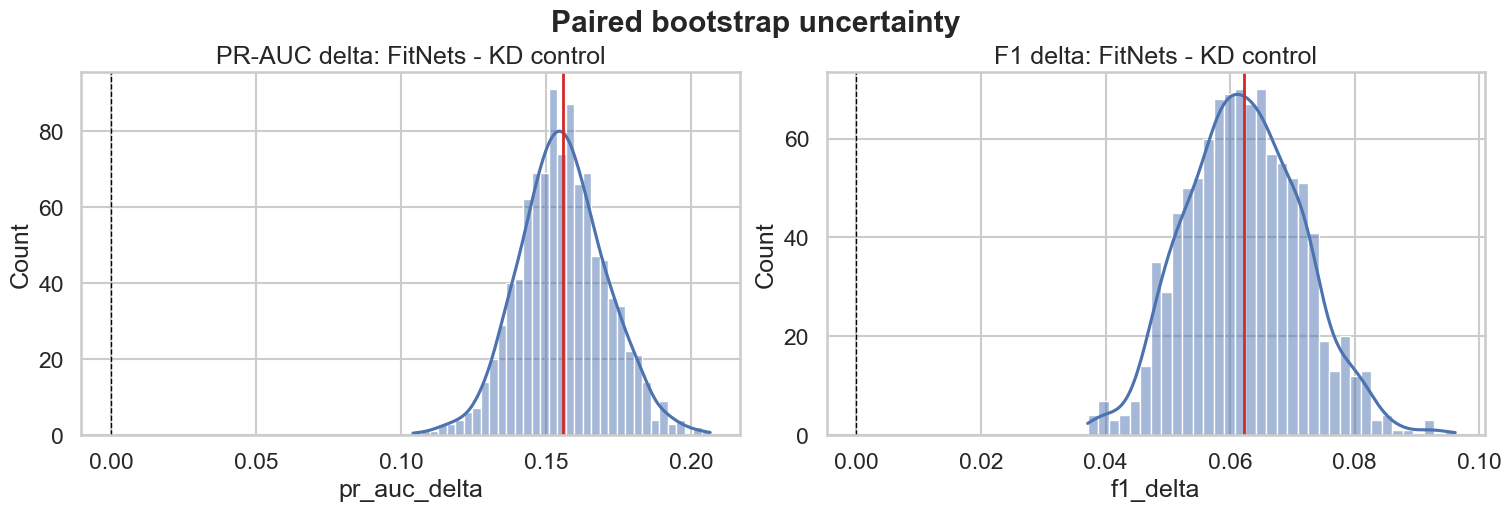

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for axis, metric, title in zip(
    axes,
    ("pr_auc_delta", "f1_delta"),
    ("PR-AUC delta", "F1 delta"),
):
    sns.histplot(bootstrap[metric], bins=35, kde=True, ax=axis)
    axis.axvline(0, color="black", linestyle="--", linewidth=1)
    axis.axvline(bootstrap[metric].mean(), color="tab:red", linewidth=2)
    axis.set_title(title + ": FitNets - KD control")
fig.suptitle("Paired bootstrap uncertainty", fontweight="bold")
fig.savefig(FIGURE_DIR / "fitnets_bootstrap_deltas.png", dpi=180)
plt.show()

## 9 - Representation evidence: did the hint change the student feature geometry?

In [50]:
def centered_linear_cka(first, second, epsilon=1e-12):
    first = np.asarray(first, dtype=np.float64)
    second = np.asarray(second, dtype=np.float64)
    first_gram = first @ first.T
    second_gram = second @ second.T
    count = first_gram.shape[0]
    centering = np.eye(count) - np.ones((count, count)) / count
    first_centered = centering @ first_gram @ centering
    second_centered = centering @ second_gram @ centering
    numerator = np.sum(first_centered * second_centered)
    denominator = np.sqrt(
        np.sum(first_centered**2) * np.sum(second_centered**2)
    )
    return float(numerator / max(denominator, epsilon))


def collect_hint_features(student_model, frame):
    student_features = feature_view(student_model, student_guided_layer)
    teacher_features = feature_view(teacher, teacher_hint_layer)
    batches = make_dataset(frame, False, SEED)
    teacher_values, student_values = [], []
    for inputs, _ in batches:
        teacher_values.append(teacher_features(inputs["teacher_image"], training=False).numpy())
        student_values.append(student_features(inputs["student_image"], training=False).numpy())
    return np.concatenate(teacher_values), np.concatenate(student_values)

In [51]:
diagnostic_frame = splits["test"].iloc[: config["data"]["feature_diagnostic_samples"]]
fitted_regressor = tf.keras.models.load_model(HINT_REGRESSOR, compile=False)
feature_rows = []

diagnostic_models = {
    "shared_initial": INITIAL_CORE,
    "hint_checkpoint": HINTED_CORE,
    "kd_control_final": models["kd_control"],
    "fitnets_final": models["fitnets_hint_kd"],
}
for name, path in diagnostic_models.items():
    model = tf.keras.models.load_model(path, compile=False)
    teacher_feature, student_feature = collect_hint_features(model, diagnostic_frame)
    regressed = fitted_regressor(student_feature, training=False).numpy()
    flattened_teacher = teacher_feature.reshape(len(teacher_feature), -1)
    flattened_student = student_feature.reshape(len(student_feature), -1)
    feature_rows.append(
        {
            "model": name,
            "linear_cka": centered_linear_cka(flattened_teacher, flattened_student),
            "hint_mse_with_stage1_regressor": float(
                np.mean((teacher_feature - regressed) ** 2)
            ),
        }
    )

feature_diagnostics = pd.DataFrame(feature_rows)
feature_diagnostics.to_csv(REPORT_DIR / "feature_diagnostics.csv", index=False)
display(feature_diagnostics)

,model,linear_cka,hint_mse_with_stage1_regressor
0,shared_initial,0.326586,4.203131
1,hint_checkpoint,0.956203,0.610759
2,kd_control_final,0.617190,1.586601
3,fitnets_final,0.917721,0.842921


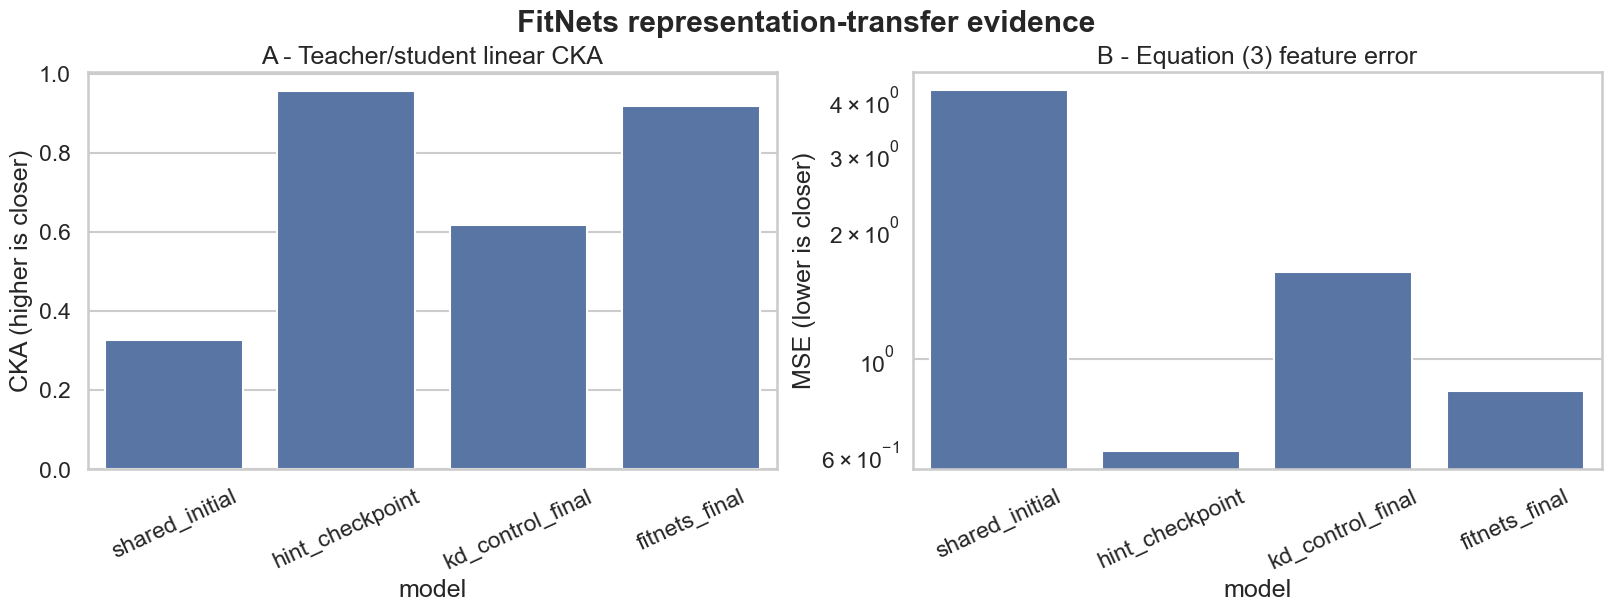

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.barplot(data=feature_diagnostics, x="model", y="linear_cka", ax=axes[0])
sns.barplot(
    data=feature_diagnostics,
    x="model",
    y="hint_mse_with_stage1_regressor",
    ax=axes[1],
)
axes[0].set(title="A - Teacher/student linear CKA", ylabel="CKA (higher is closer)")
axes[1].set(title="B - Equation (3) feature error", ylabel="MSE (lower is closer)")
axes[1].set_yscale("log")
for axis in axes:
    axis.tick_params(axis="x", rotation=25)
fig.suptitle("FitNets representation-transfer evidence", fontweight="bold")
fig.savefig(FIGURE_DIR / "fitnets_feature_similarity.png", dpi=180)
plt.show()

## 10 - Graph identity and float acceptance gates

In [53]:
graph_rows = []
for name, path in models.items():
    model = tf.keras.models.load_model(path, compile=False)
    _, _, profile = profile_model(
        model, batch_size=1, training_batch_size=BATCH_SIZE
    )
    graph_rows.append(
        {
            "model": name,
            "parameters": profile["parameters"],
            "macs": profile["estimated_macs_batch1"],
            "peak_int8_activation": profile[
                "peak_live_activation_int8_bytes_batch1_hypothetical"
            ],
        }
    )
graph = pd.DataFrame(graph_rows)
graph.to_csv(REPORT_DIR / "graph_identity.csv", index=False)
display(graph)

,model,parameters,macs,peak_int8_activation
0,hard_control,218801,10487648,117136
1,kd_control,218801,10487648,117136
2,fitnets_hint_kd,218801,10487648,117136


In [54]:
quality_by_model = quality.set_index("model")
feature_by_model = feature_diagnostics.set_index("model")
kd_row = quality_by_model.loc["kd_control"]
fitnets_row = quality_by_model.loc["fitnets_hint_kd"]

gates = {
    "pr_auc_gain": bool(
        fitnets_row.pr_auc
        >= kd_row.pr_auc + config["acceptance_gate"]["minimum_pr_auc_gain"]
    ),
    "f1_retained": bool(
        fitnets_row.f1
        >= kd_row.f1 - config["acceptance_gate"]["maximum_f1_drop"]
    ),
    "specificity_retained": bool(
        fitnets_row.specificity
        >= kd_row.specificity
        - config["acceptance_gate"]["maximum_specificity_drop"]
    ),
    "feature_alignment_gain": bool(
        feature_by_model.loc["fitnets_final", "linear_cka"]
        >= feature_by_model.loc["kd_control_final", "linear_cka"]
        + config["acceptance_gate"]["minimum_cka_gain"]
    ),
    "graph_identity": bool(graph.drop(columns="model").nunique().max() == 1),
}
gates["accepted_float"] = all(gates.values())
(REPORT_DIR / "acceptance_gates.json").write_text(
    json.dumps(gates, indent=2), encoding="utf-8"
)
display(pd.Series(gates))

pr_auc_gain               True
f1_retained               True
specificity_retained      True
feature_alignment_gain    True
graph_identity            True
accepted_float            True
dtype: bool

## 11 - Conditional full-INT8 export and desktop parity

In [55]:
TFLITE_PATH = MODEL_DIR / config["export"]["model_filename"]


def representative_dataset():
    count = 0
    for images, _ in val_ds:
        for image in images:
            yield [image.numpy()[None].astype(np.float32)]
            count += 1
            if count >= config["export"]["representative_samples"]:
                return


if gates["accepted_float"] and RUN_INT8_EXPORT:
    fitnets_model = tf.keras.models.load_model(
        models["fitnets_hint_kd"], compile=False
    )
    convert_full_integer(fitnets_model, representative_dataset(), TFLITE_PATH)
    export_info = inspect_tflite(TFLITE_PATH)
    (REPORT_DIR / "export_info.json").write_text(
        json.dumps(export_info, indent=2), encoding="utf-8"
    )
    display(pd.Series(export_info))
else:
    export_info = None
    print("INT8 export skipped: FitNets float gates did not all pass.")

INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp041y0th1/assets


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp041y0th1/assets


Saved artifact at '/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp041y0th1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 120, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5058442192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058469328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058471440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058464752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058467040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058476368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058514432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058513904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058475664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058510912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5058517248: TensorSpec(shap

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1790841343.135685  494965 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790841343.135708  494965 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790841343.171635  494965 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://

size_bytes                                               304944
input         {'name': 'serving_default_image:0', 'shape': [...
output        {'name': 'StatefulPartitionedCall_1:0', 'shape...
operators     [ADD, CONV_2D, DEPTHWISE_CONV_2D, FULLY_CONNEC...
dtype: object

In [56]:
def predict_tflite(path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero = input_detail["quantization"]
    output_scale, output_zero = output_detail["quantization"]
    labels, outputs = [], []
    for images, batch_labels in dataset:
        labels.extend(np.asarray(batch_labels).reshape(-1).astype(int))
        for image in np.asarray(images):
            quantized = np.clip(
                np.round(image / input_scale + input_zero), -128, 127
            ).astype(np.int8)[None]
            interpreter.set_tensor(input_detail["index"], quantized)
            interpreter.invoke()
            raw = interpreter.get_tensor(output_detail["index"])[0, 0]
            outputs.append((float(raw) - output_zero) * output_scale)
    return np.asarray(labels), np.asarray(outputs)


if export_info:
    _, int8_validation_probability = predict_tflite(TFLITE_PATH, val_ds)
    _, int8_test_probability = predict_tflite(TFLITE_PATH, test_ds)
    int8_threshold = select_threshold(
        validation_labels,
        int8_validation_probability,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=config["evaluation"]["minimum_recall"],
        false_positive_cost=config["evaluation"]["false_positive_cost"],
        false_negative_cost=config["evaluation"]["false_negative_cost"],
    )["threshold"]
    int8_metrics = classification_metrics(
        test_labels, int8_test_probability, int8_threshold
    )
    parity = {
        "probability_mae": float(
            np.mean(
                np.abs(
                    int8_test_probability - probabilities["fitnets_hint_kd"]
                )
            )
        ),
        "f1_delta": float(int8_metrics["f1"] - fitnets_row.f1),
        "pr_auc_delta": float(int8_metrics["pr_auc"] - fitnets_row.pr_auc),
    }
    parity["passed"] = bool(
        parity["probability_mae"]
        <= config["acceptance_gate"]["maximum_float_to_int8_probability_mae"]
    )
    (REPORT_DIR / "int8_metrics.json").write_text(
        json.dumps(int8_metrics, indent=2), encoding="utf-8"
    )
    (REPORT_DIR / "float_to_int8_parity.json").write_text(
        json.dumps(parity, indent=2), encoding="utf-8"
    )
    print({"int8": int8_metrics, "parity": parity})
else:
    int8_metrics = None
    parity = None

{'int8': {'samples': 2000, 'threshold': 0.17500000000000002, 'accuracy': 0.6925, 'precision': 0.6401225114854517, 'recall': 0.8521916411824668, 'f1': 0.7310887625710538, 'roc_auc': 0.8059169360139009, 'pr_auc': 0.7991797260519714, 'specificity': 0.5387634936211972, 'confusion_matrix': [[549, 470], [145, 836]], 'positive_prevalence': 0.4905, 'predicted_positive_rate': 0.653}, 'parity': {'probability_mae': 0.014112983132712543, 'f1_delta': -7.485758052883096e-05, 'pr_auc_delta': 0.0007105455087356161, 'passed': True}}


## 12 - Final machine-readable and Markdown reports

In [57]:
def json_default(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Cannot JSON-encode {type(value)}")


summary = {
    "experiment": config["project"]["name"],
    "paper_algorithm": {
        "stage1": "Equation 3 hint regression",
        "stage2": "Equation 2 hard plus softened teacher cross-entropy",
        "temperature": TEMPERATURE,
        "lambda_start": config["training"]["lambda_start"],
        "lambda_end": config["training"]["lambda_end"],
        "teacher_hint_layer": teacher_hint_layer,
        "student_guided_layer": student_guided_layer,
    },
    "contract": contract,
    "quality": quality.to_dict("records"),
    "bootstrap": bootstrap_summary.to_dict("records"),
    "feature_diagnostics": feature_diagnostics.to_dict("records"),
    "graph": graph.to_dict("records"),
    "gates": gates,
    "int8_export": export_info,
    "int8_metrics": int8_metrics,
    "float_to_int8_parity": parity,
    "physical_profile_complete": False,
}
(REPORT_DIR / "experiment_summary.json").write_text(
    json.dumps(summary, indent=2, default=json_default), encoding="utf-8"
)

5656

In [58]:
def markdown_table(frame):
    columns = list(frame.columns)
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for row in frame.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(str(value) for value in row) + " |")
    return "\n".join(lines)


report_lines = [
    "# FitNets feature-hint report",
    "",
    "- Paper: Romero et al., FitNets: Hints for Thin Deep Nets (ICLR 2015)",
    f"- Temperature: **{TEMPERATURE:g}**",
    f"- Lambda curriculum: **{config['training']['lambda_start']:g} -> {config['training']['lambda_end']:g}**",
    f"- Float accepted: **{gates['accepted_float']}**",
    "- Physical profiling complete: **False**",
    "",
    "## Quality",
    "",
    markdown_table(quality.round(6)),
    "",
    "## Representation diagnostics",
    "",
    markdown_table(feature_diagnostics.round(6)),
    "",
    "## Acceptance gates",
    "",
    markdown_table(pd.DataFrame([gates])),
    "",
]
report_path = REPORT_DIR / "FITNETS_REPORT.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print(report_path)

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/fitnets_student_120/reports/FITNETS_REPORT.md


## Next decision

- If `fitnets_hint_kd` improves the same `kd_control`, passes the specificity and representation
  gates, and survives INT8 conversion, profile it on ESP32-S3 first and ESP32-CAM second.
- If Equation (3) reduces hint error but test quality does not improve, keep this as a valid
  negative paper-anchor result. The next registered ablation is normalized feature MSE, not an
  unbounded hyperparameter sweep.
- If hint loss does not fall, debug the layer pair, RGB shared-view contract, regressor shape,
  and prefix gradients before changing the technique.
- Do not begin QAT until one float student has passed the acceptance gates.